# Pipeline Cross-Check

This project builds the OMOP transform twice: once in `src/transform/` (pandas,
the pipeline `python -m src.main --stage all` runs), and once independently in
`dbt/models/marts/` (SQL, the pipeline `dbt build` runs) — see
[ADR 0002](../docs/adr/0002-dbt-independent-implementation.md) for why this is a
second build against its own `cdm_dbt` schema rather than a shared writer. Two
unrelated code paths reading the same staging tables and landing on the same row
counts is a real cross-check on both, not a demonstration in search of a chart.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, "..")
sys.path.insert(0, ".")
from src.config.settings import settings

# Jupyter's kernel CWD is this notebook's own folder, but settings.duckdb_path
# defaults to a path relative to CWD — left alone, that resolves to
# notebooks/data/... and every query below would silently open a fresh,
# empty database instead of the real one at the repo root.
settings.duckdb_path = Path("../data/processed/omop_demo.duckdb")
import duckdb

con = duckdb.connect("../data/processed/omop_demo.duckdb")

tables = ["person", "visit_occurrence", "condition_occurrence", "drug_exposure", "measurement"]
for table in tables:
    pandas_n = con.execute(f"select count(*) from cdm.{table}").fetchone()[0]
    dbt_n = con.execute(f"select count(*) from cdm_dbt.{table}").fetchone()[0]
    print(f"{table:24s} pandas={pandas_n:>8,}  dbt={dbt_n:>8,}  match={pandas_n == dbt_n}")
con.close()


person                   pandas=   3,000  dbt=   3,000  match=True
visit_occurrence         pandas=  76,548  dbt=  76,548  match=True
condition_occurrence     pandas=   4,180  dbt=   4,180  match=True
drug_exposure            pandas=   2,950  dbt=   2,950  match=True
measurement              pandas= 413,950  dbt= 413,950  match=True


## The chart

Not a bar chart — the question here isn't magnitude, it's identity, and a bar
chart's whole job is ranking things by size. Each table gets the same EKG
waveform traced twice, once per pipeline, from the same jitter seed, offset by
two pixels — where the two pipelines agree, both colors peek out along a single
shared line instead of resolving into two visibly different traces. If a table's
counts ever diverged, this is also the chart that would show it happening,
rather than hiding a mismatch behind two numbers a reader has to compare by eye.


Saved docs/assets/visualizations/pipeline_crosscheck.svg and pipeline_crosscheck.png


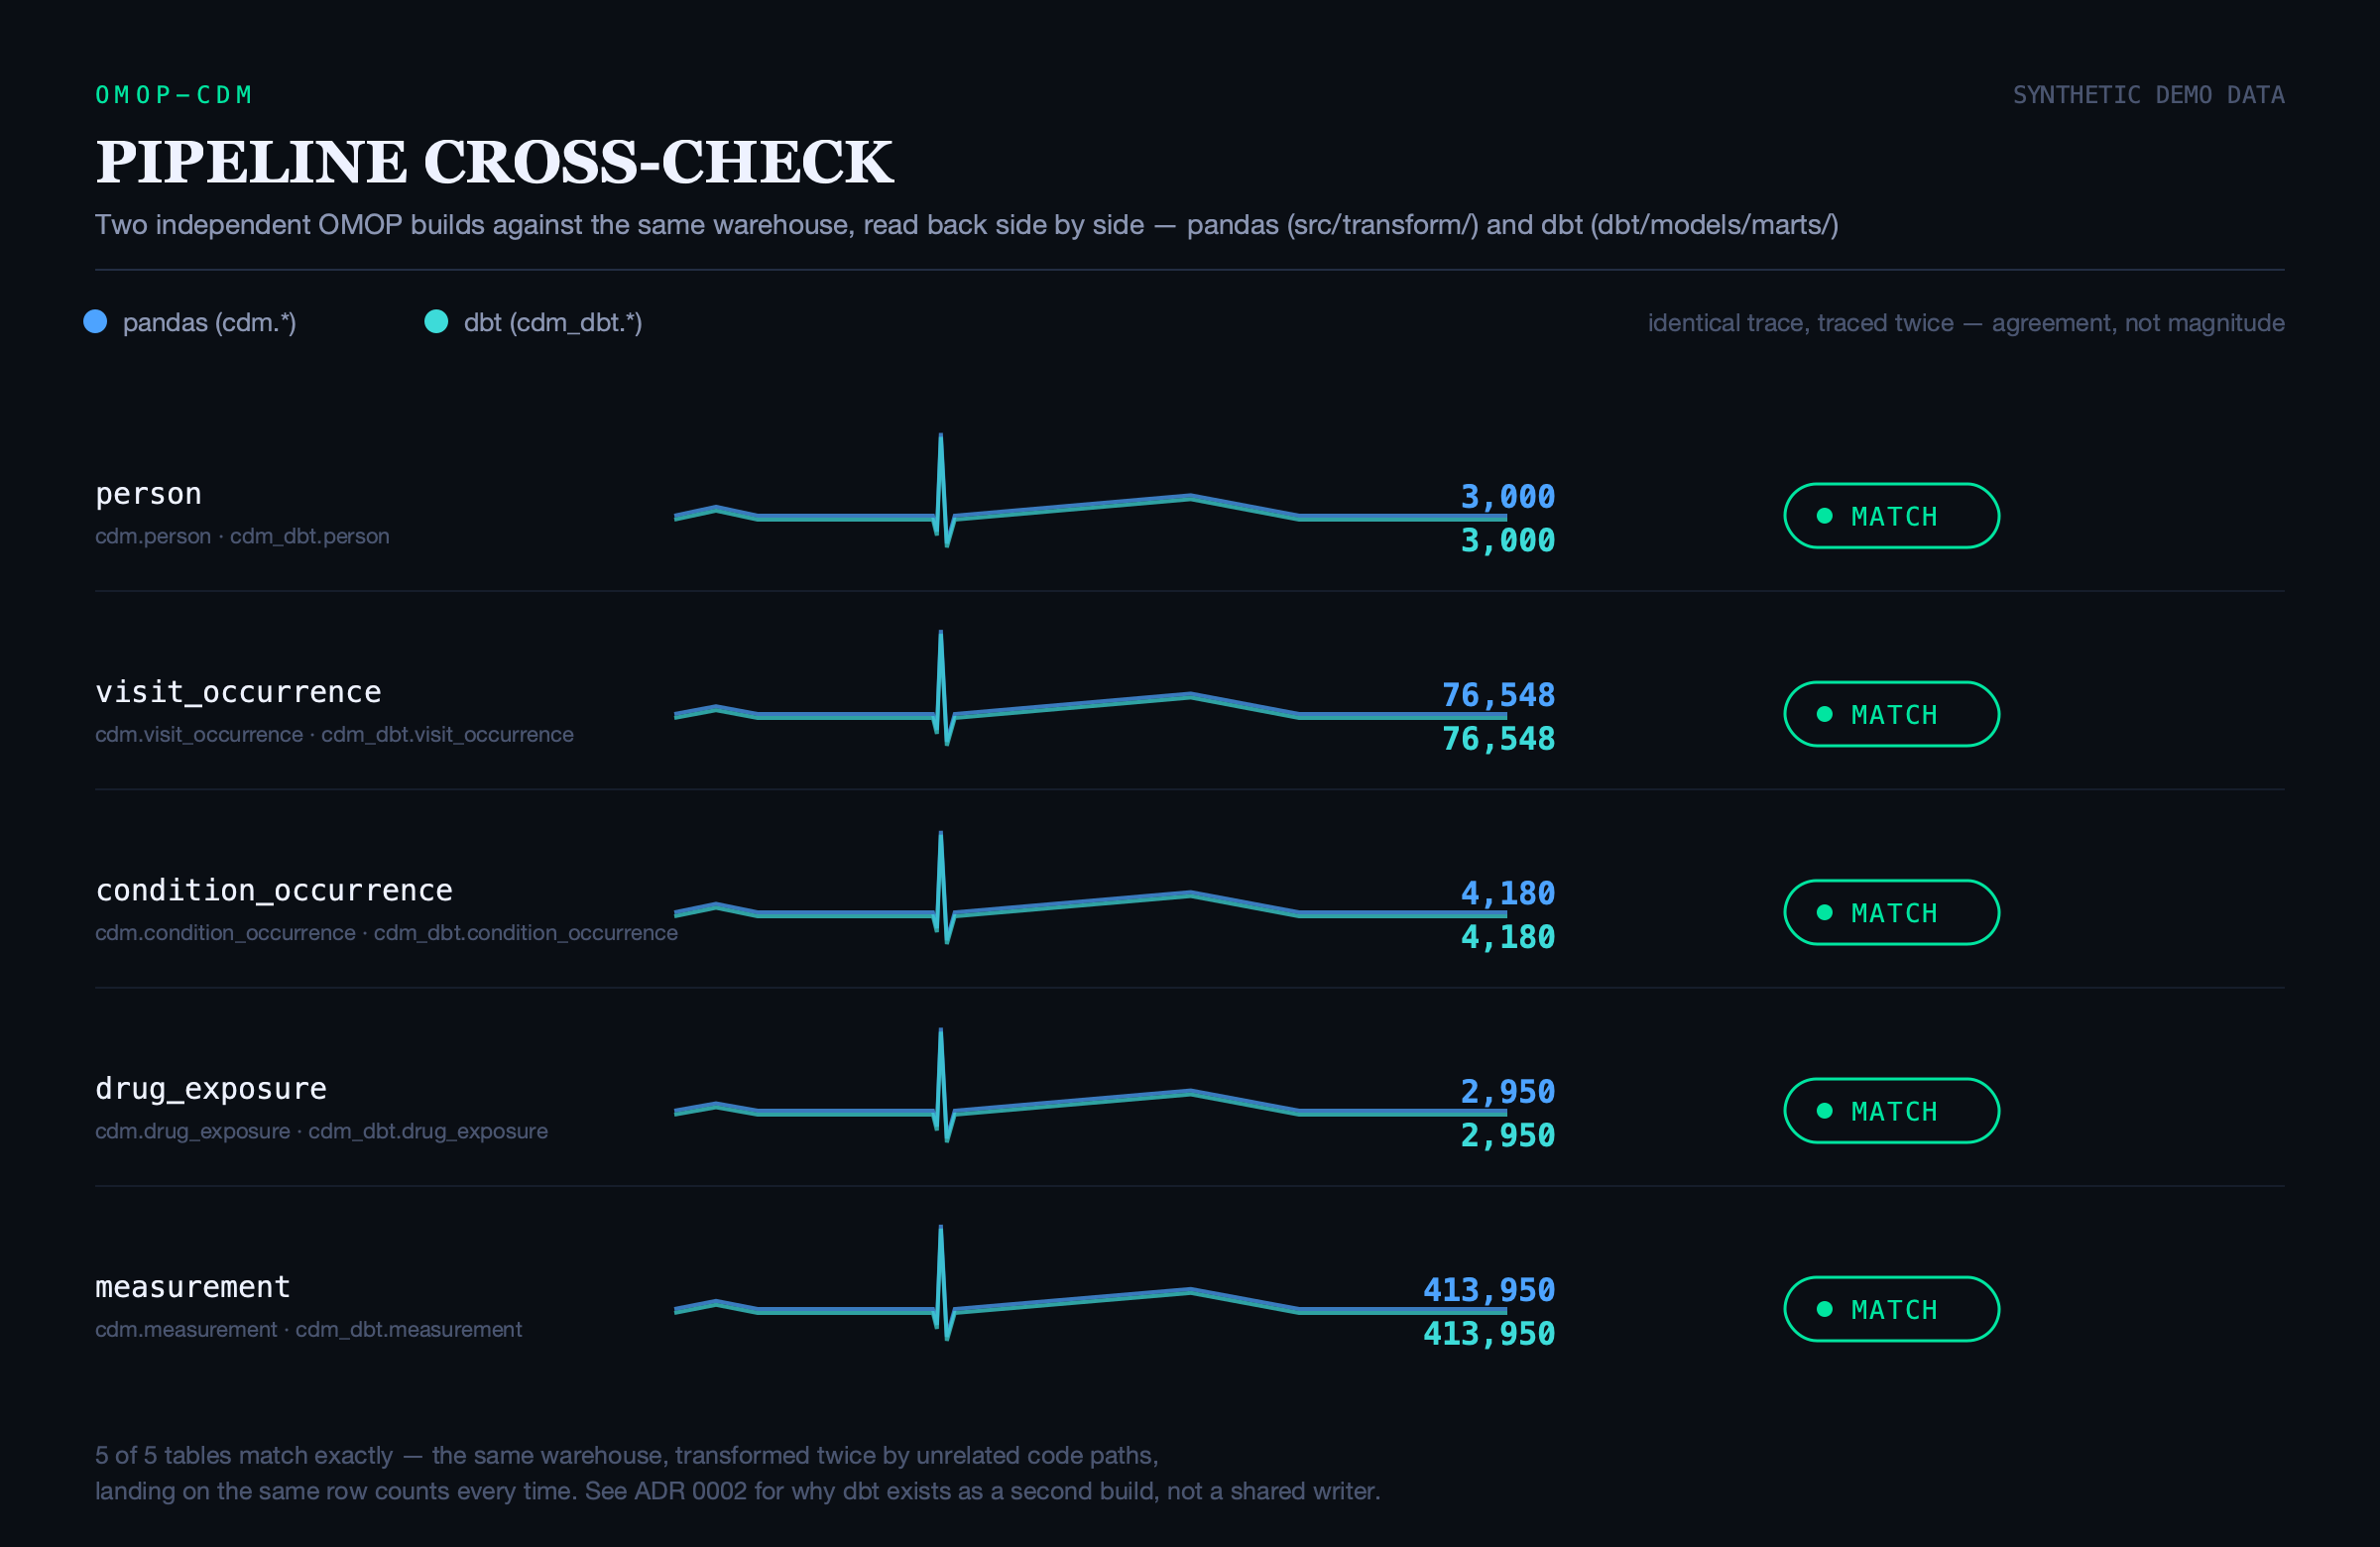

In [2]:
import subprocess
import sys

from IPython.display import Image

subprocess.run([sys.executable, "notebooks/build_pipeline_crosscheck.py"], cwd="..", check=True)
Image(filename="../docs/assets/visualizations/pipeline_crosscheck.png")


## Reading this

All five tables match exactly, at every scale from 2,950 rows to 413,950. That's
not a coincidence worth shrugging at — `src/transform/omop_transformer.py` and
`dbt/models/marts/*.sql` share no code, no ORM, no common query layer, only the
same staging tables and the same OMOP spec to reshape them against. Agreement at
this scale is the actual evidence that both implementations are correct, not just
self-consistent.
